In [1]:
# %load_ext IPython.extensions.autoreload
# %autoreload 2

import os
import sys
import joblib
import onnxruntime as ort
import numpy as np
from src.helpers import cst_to_coords
from pathlib import Path
from aerosandbox import Airfoil
from src.airfoil import airfoil_modifications

# Find the project root (the nearest ancestor that contains `src`) and add it to sys.path
cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent
else:
    project_root = cwd

proj_path = str(project_root.resolve())
if proj_path not in sys.path:
    # Insert at front so local packages take precedence
    sys.path.insert(0, proj_path)

In [2]:
RUN_ID = "20260221-165429"
LATENT_DIM = 16

BASE_DIR = Path(proj_path)
MODELS_PATH = BASE_DIR / "models"
ONNX_MODEL_PATH = MODELS_PATH / "onnx_decoder"

SCALER_PATH = ONNX_MODEL_PATH / f"{RUN_ID}_scaler.pkl"
DECODER_PATH = ONNX_MODEL_PATH / f"{RUN_ID}_decoder.onnx"

In [54]:
# ============================================================================
# 2. INFERÊNCIA E PLOTAGEM
# ============================================================================
# 1. Carregar o Scaler
scaler = joblib.load(SCALER_PATH)

# 2. Iniciar Sessão ONNX
session = ort.InferenceSession(DECODER_PATH)
input_name = session.get_inputs()[0].name

# 3. Criar Vetor Latente Aleatório (Batch=1, LatentDim=16)
# A distribuição normal garante que o formato gerado seja realista
z_random = np.random.normal(0, 1.0, size=(1, LATENT_DIM)).astype(np.float32)

# 4. Rodar Inferência
outputs = session.run(None, {input_name: z_random})

# O ONNX retorna os tensores crus (w_norm e p_norm)
w_norm = outputs[0] 
p_norm = outputs[1] 

# 5. Desnormalizar os dados
w_phys, p_phys = scaler.inverse_transform(w_norm, p_norm)

# 6. Gerar Coordenadas CST
x_coords, y_coords = cst_to_coords(w_phys[0], p_phys[0], n_points=100)

coords = np.stack((x_coords, y_coords), axis=-1)

af = Airfoil(coordinates=coords)
af.draw()

In [55]:
re = [1e6]
mach = 0.2
Aero = af.get_aero_from_neuralfoil(
    alpha=np.linspace(0, 18, 40),
    Re=re,
    mach=mach,
    model_size="xlarge",
)
confidence_sweep = Aero["analysis_confidence"]
print(confidence_sweep)
print(np.mean(confidence_sweep))

[0.94622656 0.94583889 0.94599514 0.94729758 0.95070417 0.94838305
 0.94035841 0.93628039 0.93151398 0.92831507 0.92799247 0.92955074
 0.93324528 0.93797987 0.94128214 0.94175094 0.93874371 0.93153951
 0.918977   0.89942553 0.8709107  0.83133274 0.77887986 0.71280497
 0.63454476 0.54865928 0.46253824 0.38421087 0.31931929 0.26938059
 0.2320626  0.20255561 0.17614456 0.15192316 0.13223598 0.1183074
 0.10926817 0.10353045 0.09989612 0.09760206]
0.6489376956026235


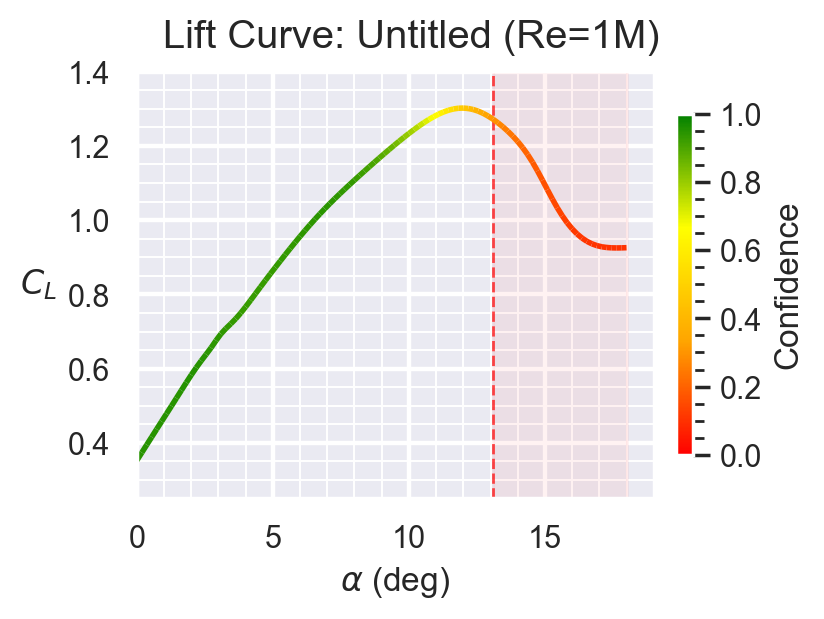

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from aerosandbox.tools.string_formatting import eng_string
import aerosandbox.tools.pretty_plots as p

# --- 1. SETTINGS & THRESHOLD ---
CONFIDENCE_THRESHOLD = 0.3
# Adjust figsize here: (width, height) in inches
# (5, 3) is quite small; (8, 5) is standard desktop size
FIG_SIZE = (4, 3) 

re = [1e6]
mach = 0.2
alpha_range = np.linspace(0, 18, 100)

# --- 2. DATA ---
Aero = af.get_aero_from_neuralfoil(
    alpha=alpha_range,
    Re=re,
    mach=mach,
    model_size="xlarge",
)

cl_data = np.atleast_2d(Aero["CL"])
confidence_data = np.atleast_2d(Aero["analysis_confidence"])

# --- 3. PLOTTING ---
# We apply the figsize here to make the plot smaller on your screen
fig, ax = plt.subplots(figsize=FIG_SIZE)

cmap = LinearSegmentedColormap.from_list("conf", ["red", "orange", "yellow", "green"])
norm = plt.Normalize(0, 1)

for i in range(len(re)):
    x = alpha_range
    y = cl_data[i, :]
    conf = confidence_data[i, :]

    # Find the drop-off point
    low_conf_mask = conf < CONFIDENCE_THRESHOLD
    if np.any(low_conf_mask):
        alpha_crit = x[np.where(low_conf_mask)[0][0]]
        
        # Draw vertical line
        ax.axvline(x=alpha_crit, color="red", linestyle="--", lw=1, alpha=0.7)
        
        # Optional: Shade the "Low Confidence" region
        ax.axvspan(alpha_crit, x.max(), color='red', alpha=0.05, label='Low Confidence Zone')

    # Multi-colored line
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
    lc.set_array((conf[:-1] + conf[1:]) / 2)
    ax.add_collection(lc)

# 4. COLORBAR & LABELS
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# 'shrink' and 'aspect' help keep the colorbar from overpowering a small plot
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
cbar.set_label("Confidence")

ax.set_xlim(alpha_range.min(), alpha_range.max() + 1)
ax.set_ylim(cl_data.min() - 0.1, cl_data.max() + 0.1)

p.show_plot(
    title=f"Lift Curve: {af.name} (Re={eng_string(re[0])})",
    xlabel="$\\alpha$ (deg)",
    ylabel="$C_L$",
)